# LSTM vs. ARIMA vs LASSO

#### a. Dependencies

In [72]:
# Dependencies
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import TimeSeriesSplit

#### b. Data

In [73]:
# Load Data
path = "C:\\Users\\sonla\\Documents\\EnergyPrices\\Data\\train.csv"
data = pd.read_csv(path)
data.head()

,Date_Begin_Local,ACTUAL_POOL_PRICE,ACTUAL_AIL,T2M_AVG,price_lag_1,price_lag_24,price_lag_168,price_rolling_std_24,is_low_wind,wind_power_proxy,is_cold_snap,T2M_sq,AIL_T2M,delta_price,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,2020-01-08 00:00:00,27.25,9869.0,-6.500000,27.15,34.48,30.24,19.989928,0,766.898405,0,42.250000,-64148.500000,0.10,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025
1,2020-01-08 01:00:00,26.63,9728.0,-6.256667,27.25,32.97,29.43,20.135990,0,942.152727,0,39.145878,-60864.853333,-0.62,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025
2,2020-01-08 02:00:00,25.41,9676.0,-6.096667,26.63,35.64,29.66,20.273845,0,974.224682,0,37.169344,-58991.346667,-1.22,0.500000,0.866025,0.974928,-0.222521,0.5,0.866025
3,2020-01-08 03:00:00,26.93,9727.0,-6.336667,25.41,35.60,28.19,20.471088,0,810.426503,0,40.153344,-61636.756667,1.52,0.707107,0.707107,0.974928,-0.222521,0.5,0.866025
4,2020-01-08 04:00:00,28.02,9808.0,-6.606667,26.93,37.01,31.17,20.616058,0,759.382576,0,43.648044,-64798.186667,1.09,0.866025,0.500000,0.974928,-0.222521,0.5,0.866025


In [32]:
data.columns

Index(['Date_Begin_Local', 'ACTUAL_POOL_PRICE', 'ACTUAL_AIL', 'T2M_AVG',
       'price_lag_1', 'price_lag_24', 'price_lag_168', 'price_rolling_std_24',
       'is_low_wind', 'wind_power_proxy', 'is_cold_snap', 'T2M_sq', 'AIL_T2M',
       'delta_price', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos'],
      dtype='object')

## 1. Exploratory Data Analysis - Mena

In [74]:
eda_df = data.copy()
eda_df['Date_Begin_Local'] = pd.to_datetime(eda_df['Date_Begin_Local'])
eda_df = eda_df.set_index('Date_Begin_Local')

#### Data Structure

In [75]:
print("Data Shape:", eda_df.shape)
print("Null Values:\n", eda_df.isnull().sum())
print("Data Types:\n", eda_df.dtypes)
print("Statistical Summary:\n", eda_df.describe())

Data Shape: (39009, 19)
Null Values:
 ACTUAL_POOL_PRICE       0
ACTUAL_AIL              0
T2M_AVG                 0
price_lag_1             0
price_lag_24            0
price_lag_168           0
price_rolling_std_24    0
is_low_wind             0
wind_power_proxy        0
is_cold_snap            0
T2M_sq                  0
AIL_T2M                 0
delta_price             0
hour_sin                0
hour_cos                0
dow_sin                 0
dow_cos                 0
month_sin               0
month_cos               0
dtype: int64
Data Types:
 ACTUAL_POOL_PRICE       float64
ACTUAL_AIL              float64
T2M_AVG                 float64
price_lag_1             float64
price_lag_24            float64
price_lag_168           float64
price_rolling_std_24    float64
is_low_wind               int64
wind_power_proxy        float64
is_cold_snap              int64
T2M_sq                  float64
AIL_T2M                 float64
delta_price             float64
hour_sin                fl

### EDA 1 - Distribution of SMP pool price and delta_price

I used the price_lag_1 showing the previous hour’s price, was used as the SMP Pool Price in the distribution analysis, as it most closely reflects the current market price.

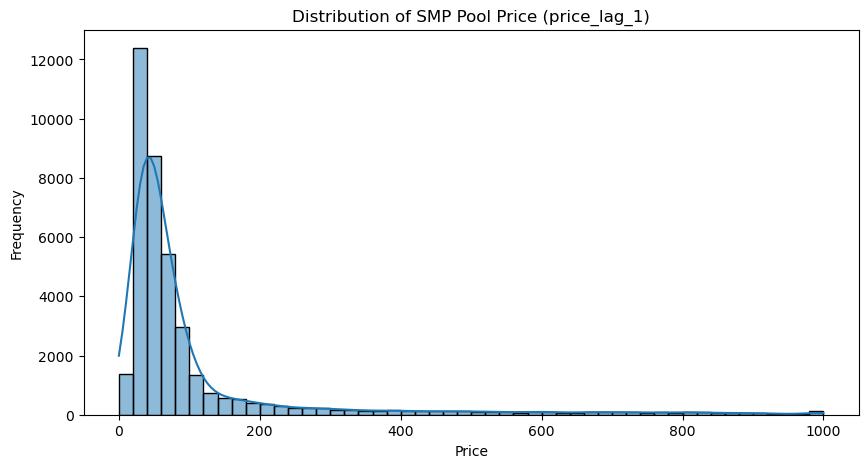

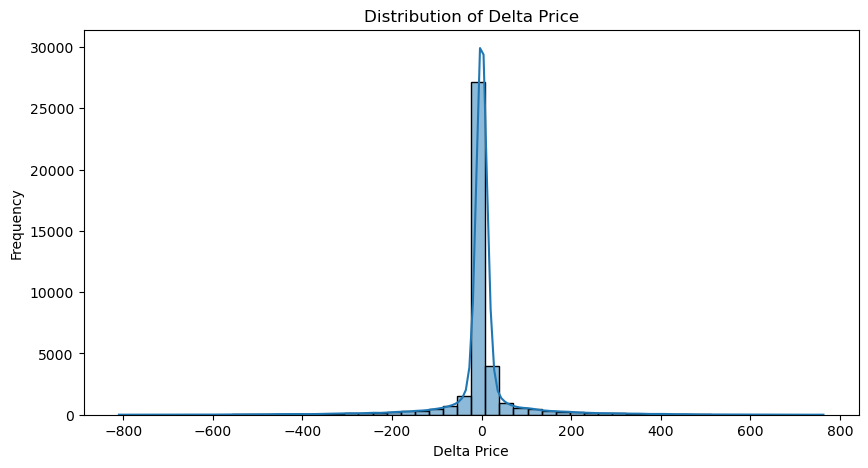

In [35]:
# Distribution of SMP Pool Price using price_lag_1
plt.figure(figsize=(10, 5))
sns.histplot(eda_df['price_lag_1'], bins=50, kde=True)
plt.title('Distribution of SMP Pool Price (price_lag_1)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Distribution of delta_price
plt.figure(figsize=(10, 5))
sns.histplot(eda_df['delta_price'], bins=50, kde=True)
plt.title('Distribution of Delta Price')
plt.xlabel('Delta Price')
plt.ylabel('Frequency')
plt.show()


**Insights**: 

### EDA 2 - Seasonality Analysis

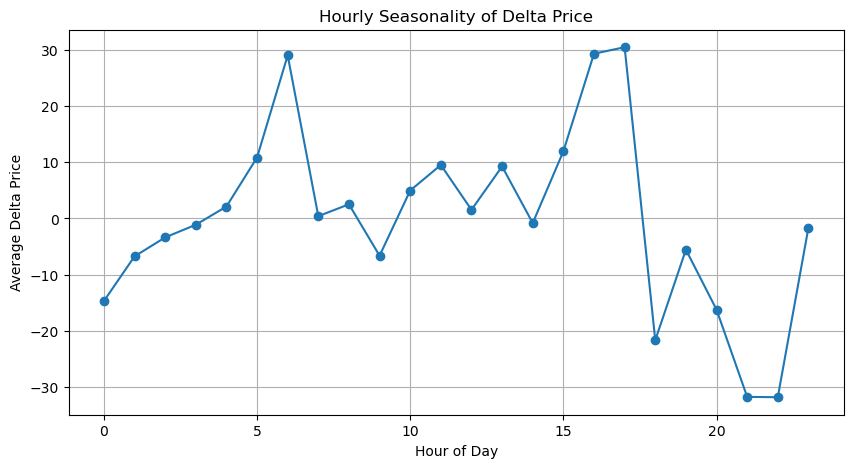

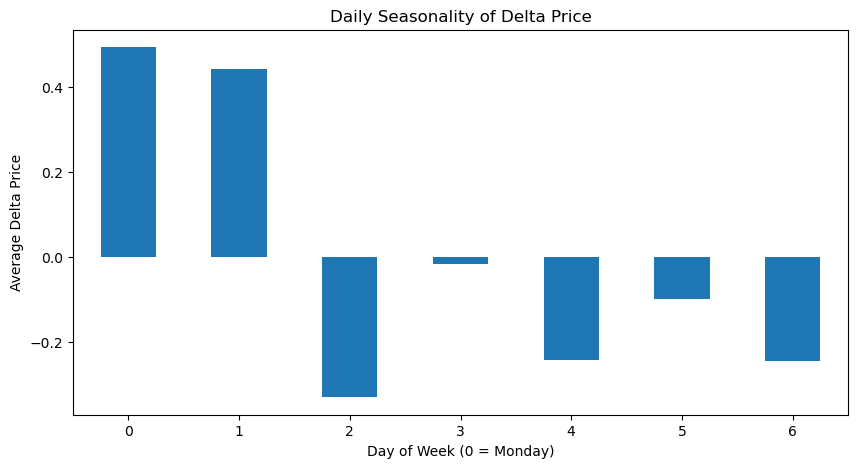

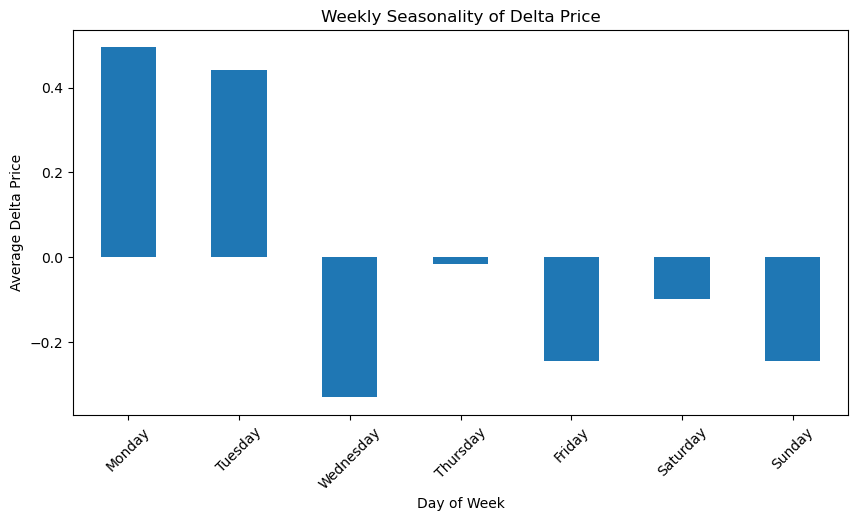

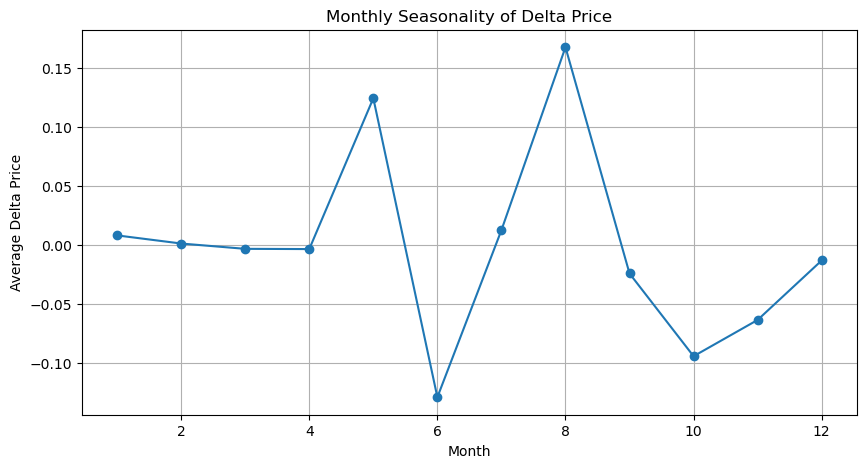

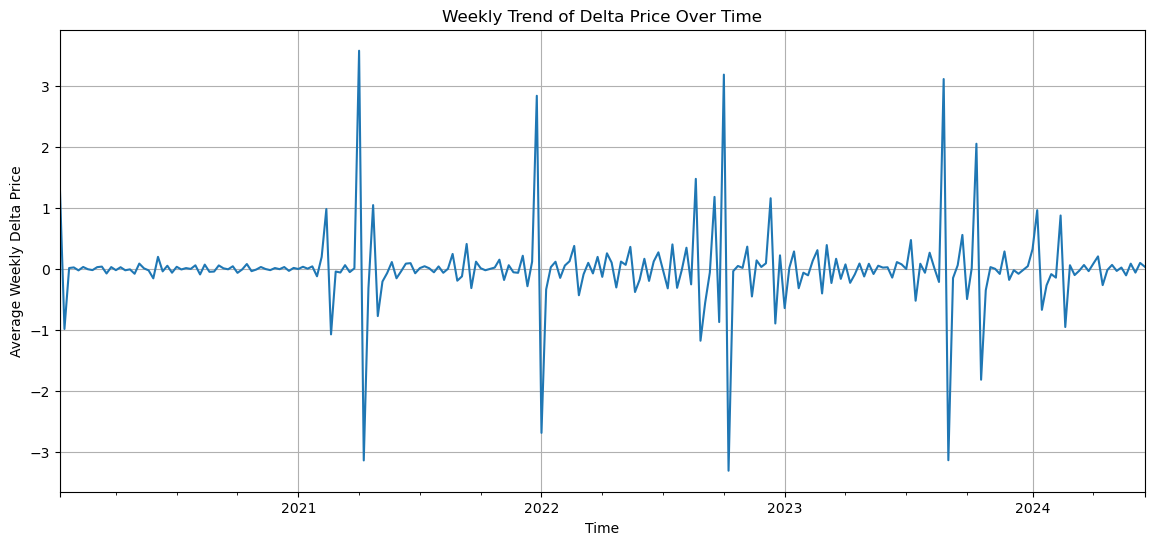

In [36]:
# Extracting useful time-based features from the index
eda_df['hour'] = eda_df.index.hour
eda_df['day_of_week'] = eda_df.index.dayofweek   # Monday = 0, Sunday = 6
eda_df['month'] = eda_df.index.month

# Creating day names for better labelling
eda_df['day_name'] = eda_df.index.day_name()

# Group delta_price by hour and compute the average
hourly_avg = eda_df.groupby('hour')['delta_price'].mean()

# Hourly pattern
plt.figure(figsize=(10, 5))
hourly_avg.plot(marker='o')
plt.title('Hourly Seasonality of Delta Price')
plt.xlabel('Hour of Day')
plt.ylabel('Average Delta Price')
plt.grid(True)
plt.show()

# Group delta_price by day of week and compute the average
daily_avg = eda_df.groupby('day_of_week')['delta_price'].mean()

# Daily pattern
plt.figure(figsize=(10, 5))
daily_avg.plot(kind='bar')
plt.title('Daily Seasonality of Delta Price')
plt.xlabel('Day of Week (0 = Monday)')
plt.ylabel('Average Delta Price')
plt.xticks(rotation=0)
plt.show()

# Weekly seasonality here means comparing average delta_price across weekdays
weekly_avg = eda_df.groupby('day_name')['delta_price'].mean()

# Reorder the days properly
weekly_avg = weekly_avg.reindex(['Monday', 'Tuesday', 'Wednesday',
                                 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Plot weekly pattern
plt.figure(figsize=(10, 5))
weekly_avg.plot(kind='bar')
plt.title('Weekly Seasonality of Delta Price')
plt.xlabel('Day of Week')
plt.ylabel('Average Delta Price')
plt.xticks(rotation=45)
plt.show()

# Group delta_price by month and compute the average
monthly_avg = eda_df.groupby('month')['delta_price'].mean()

# Monthly pattern
plt.figure(figsize=(10, 5))
monthly_avg.plot(marker='o')
plt.title('Monthly Seasonality of Delta Price')
plt.xlabel('Month')
plt.ylabel('Average Delta Price')
plt.grid(True)
plt.show()

# Resample delta_price by week to observe weekly movement over time
weekly_trend = eda_df['delta_price'].resample('W').mean()

# Weekly trend
plt.figure(figsize=(14, 6))
weekly_trend.plot()
plt.title('Weekly Trend of Delta Price Over Time')
plt.xlabel('Time')
plt.ylabel('Average Weekly Delta Price')
plt.grid(True)
plt.show()

### EDA 3 - Correlation Analysis of Features

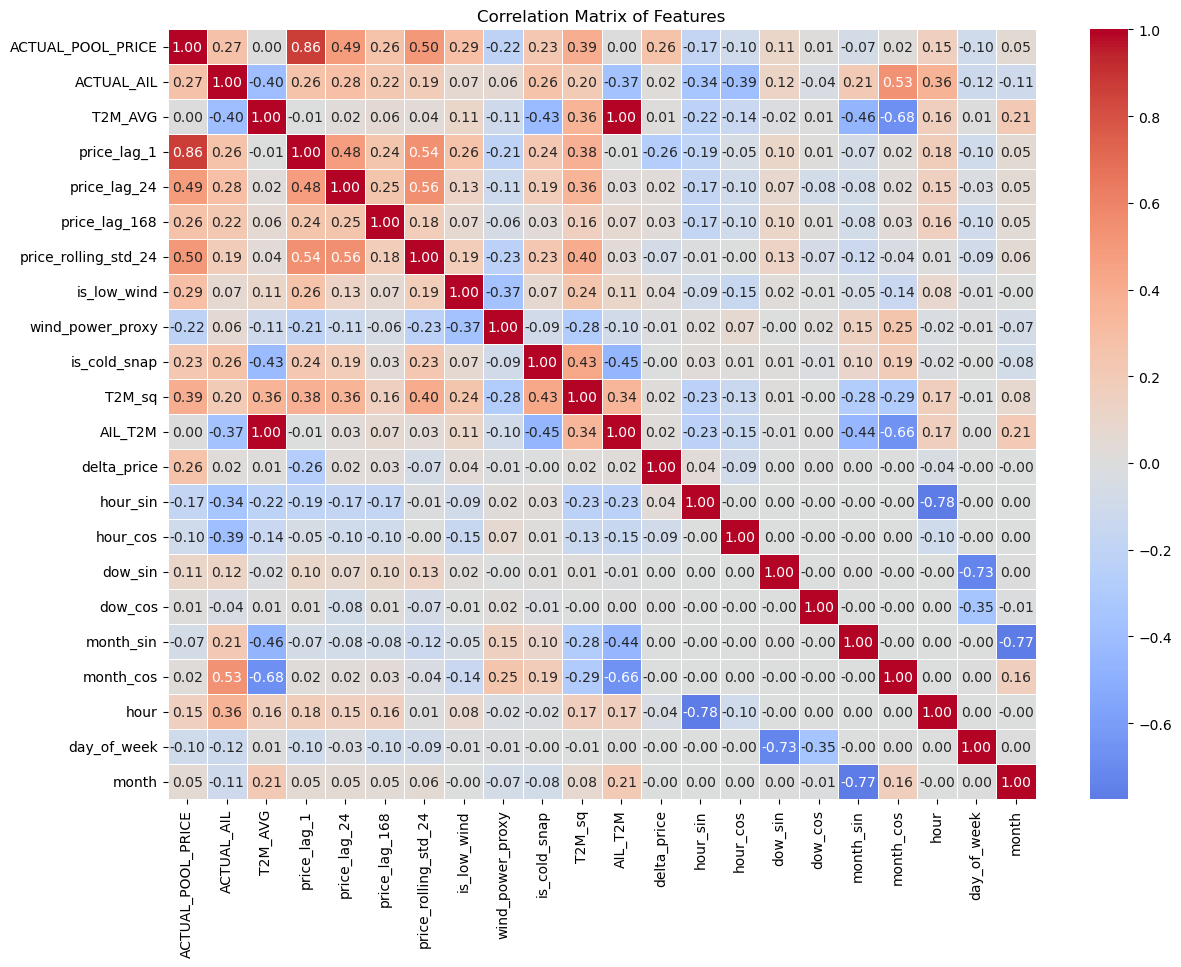

delta_price             1.000000
ACTUAL_POOL_PRICE       0.262943
is_low_wind             0.040596
hour_sin                0.037709
price_lag_168           0.028220
price_lag_24            0.023587
ACTUAL_AIL              0.019802
T2M_sq                  0.018519
AIL_T2M                 0.017275
T2M_AVG                 0.014473
dow_cos                 0.002242
dow_sin                 0.000966
month_sin               0.000076
month                  -0.000175
month_cos              -0.000236
day_of_week            -0.002685
is_cold_snap           -0.004127
wind_power_proxy       -0.008998
hour                   -0.041773
price_rolling_std_24   -0.070624
hour_cos               -0.092017
price_lag_1            -0.262945
Name: delta_price, dtype: float64


In [37]:
# Compute correlation matrix for all numerical features
corr_matrix = eda_df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Matrix of Features')
plt.show()

# Correlation with Target(delta_price)
target_corr = corr_matrix['delta_price'].sort_values(ascending=False)

print(target_corr)

Visualizing Top Correlated Features

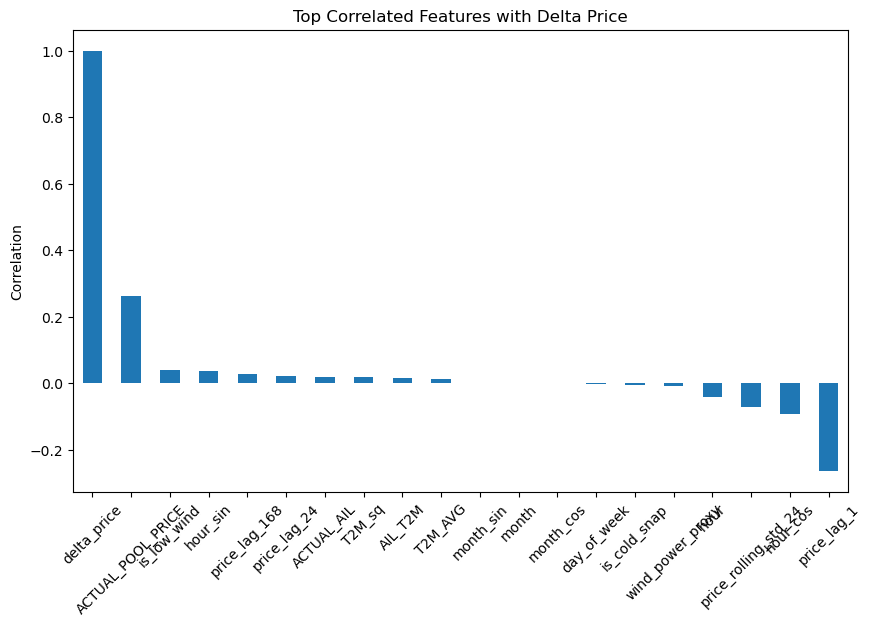

In [38]:
# Select top positively and negatively correlated features
top_features = target_corr.head(10)
bottom_features = target_corr.tail(10)

# Combining the features
important_features = pd.concat([top_features, bottom_features])

# Plot
plt.figure(figsize=(10,6))
important_features.plot(kind='bar')
plt.title('Top Correlated Features with Delta Price')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.show()

Scatter Plot for Key Features

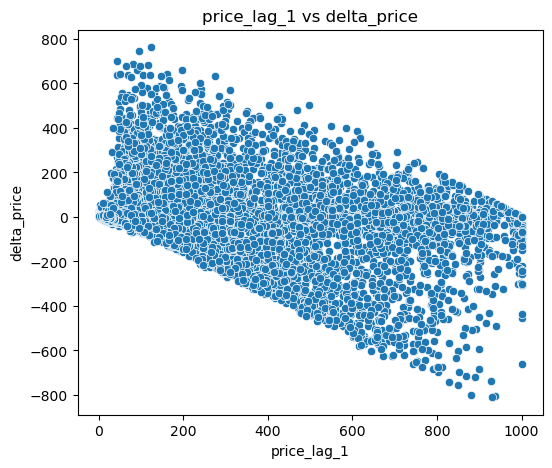

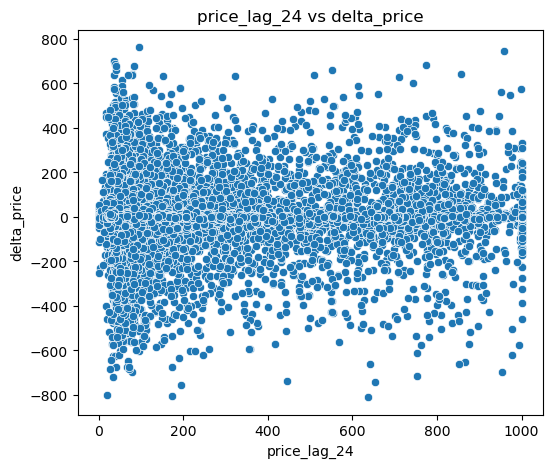

In [39]:
# price_lag_1 vs delta_price
plt.figure(figsize=(6,5))
sns.scatterplot(x='price_lag_1', y='delta_price', data=eda_df)
plt.title('price_lag_1 vs delta_price')
plt.show()

# price_lag_24 vs delta_price
plt.figure(figsize=(6,5))
sns.scatterplot(x='price_lag_24', y='delta_price', data=eda_df)
plt.title('price_lag_24 vs delta_price')
plt.show()

### EDA 4: Price Spikes and Extreme Events for Cold Snap and Chinook

Spike Threshold: 317.2507999999992


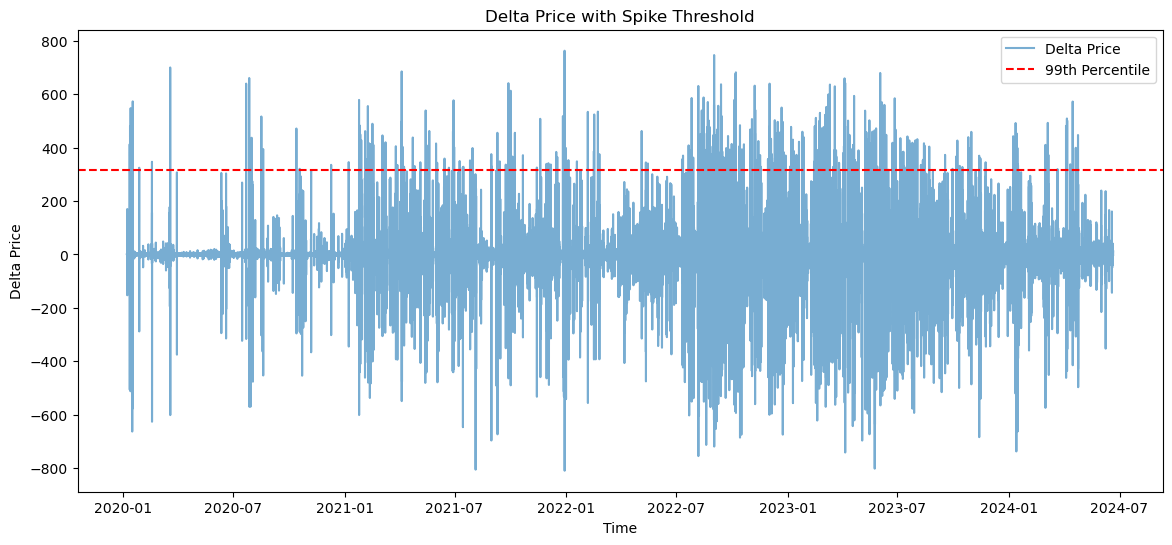

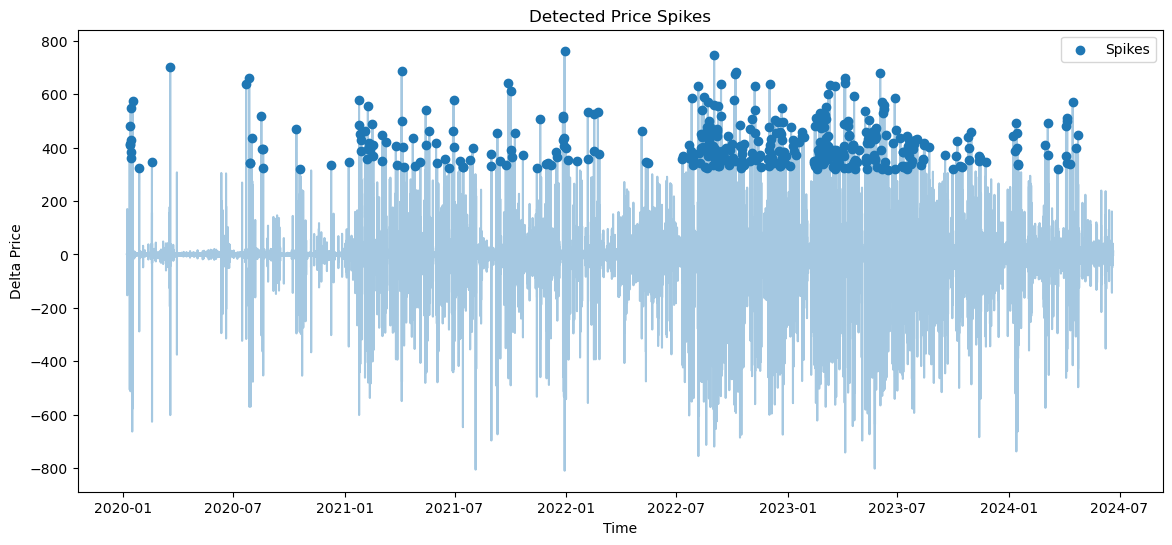

In [40]:
# Define spike threshold
threshold = eda_df['delta_price'].quantile(0.99)

print("Spike Threshold:", threshold)

# Plot delta_price  with threshold
plt.figure(figsize=(14,6))

plt.plot(eda_df.index, eda_df['delta_price'], alpha=0.6, label='Delta Price')
plt.axhline(threshold, color='red', linestyle='--', label='99th Percentile')

plt.title('Delta Price with Spike Threshold')
plt.xlabel('Time')
plt.ylabel('Delta Price')
plt.legend()
plt.show()

# Filter spike points
spikes = eda_df[eda_df['delta_price'] > threshold]

plt.figure(figsize=(14,6))
plt.plot(eda_df.index, eda_df['delta_price'], alpha=0.4)
plt.scatter(spikes.index, spikes['delta_price'], label='Spikes')

plt.title('Detected Price Spikes')
plt.xlabel('Time')
plt.ylabel('Delta Price')
plt.legend()
plt.show()

Analyzing Cold Snap Impact

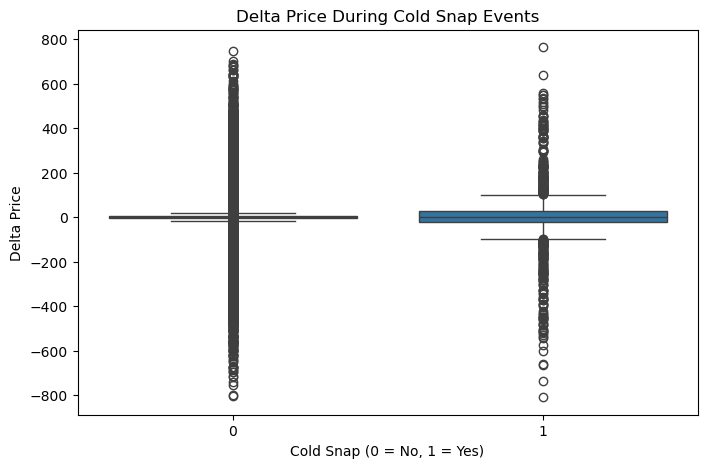

is_cold_snap
0    0.059403
1   -2.100712
Name: delta_price, dtype: float64


In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(x='is_cold_snap', y='delta_price', data=eda_df)

plt.title('Delta Price During Cold Snap Events')
plt.xlabel('Cold Snap (0 = No, 1 = Yes)')
plt.ylabel('Delta Price')
plt.show()

cold_snap_mean = eda_df.groupby('is_cold_snap')['delta_price'].mean()
print(cold_snap_mean)

## 2. Auto regressive Integrated Moving Average (ARIMA) - Mena, Tanvir

In [42]:
# Create a copy of the original data for ARIMA modeling
arima_df = data.copy()

#### Stationary Analysis for ARIMA

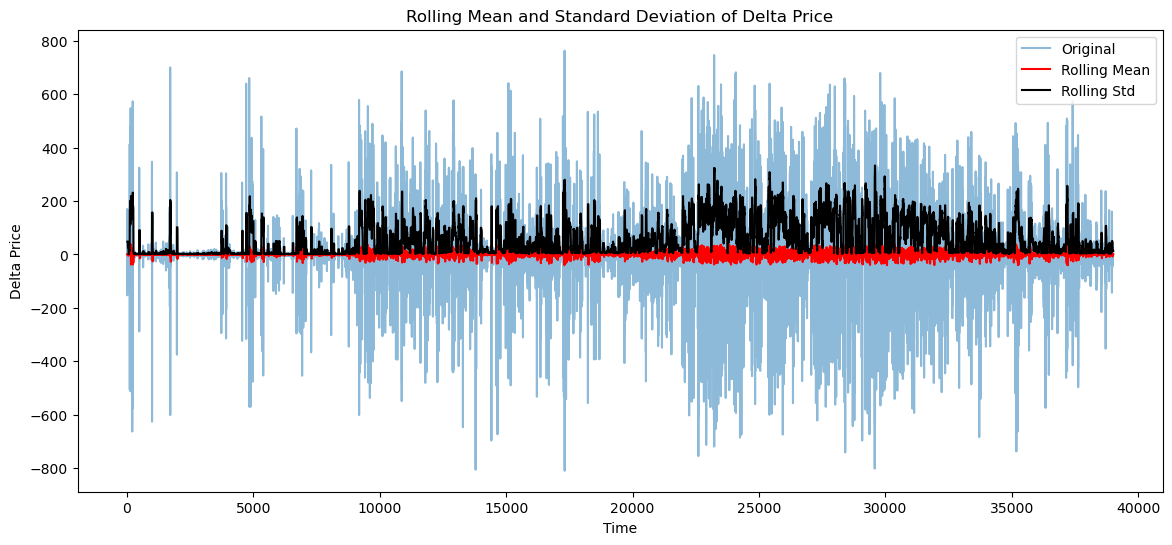

ADF Statistic: -35.8282361752634
p-value: 0.0
Critical Values:
1%: -3.430517883425858
5%: -2.8616142005626815
10%: -2.5668094945861966


In [43]:
# Rolling window 24 = 1 day since data is hourly
rolling_mean = arima_df['delta_price'].rolling(window=24).mean()
rolling_std = arima_df['delta_price'].rolling(window=24).std()

plt.figure(figsize=(14,6))

plt.plot(arima_df['delta_price'], label='Original', alpha=0.5)
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.plot(rolling_std, label='Rolling Std', color='black')

plt.title('Rolling Mean and Standard Deviation of Delta Price')
plt.xlabel('Time')
plt.ylabel('Delta Price')

plt.legend()
plt.show()

from statsmodels.tsa.stattools import adfuller

# Perform ADF test
adf_result = adfuller(arima_df['delta_price'].dropna())

# Print results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

#### Prepare Data for training ARIMA

In [44]:
# Define target series
arima_y = arima_df['delta_price'].dropna().sort_index()
print("Training target shape:", arima_y.shape)
print(arima_y.head())

# Static train-val split
arima_train_size = int(len(arima_y) * 0.8)
arima_train = arima_y.iloc[:arima_train_size]
arima_val = arima_y.iloc[arima_train_size:]

Training target shape: (39009,)
0    0.10
1   -0.62
2   -1.22
3    1.52
4    1.09
Name: delta_price, dtype: float64


#### ACF/PACF Analysis

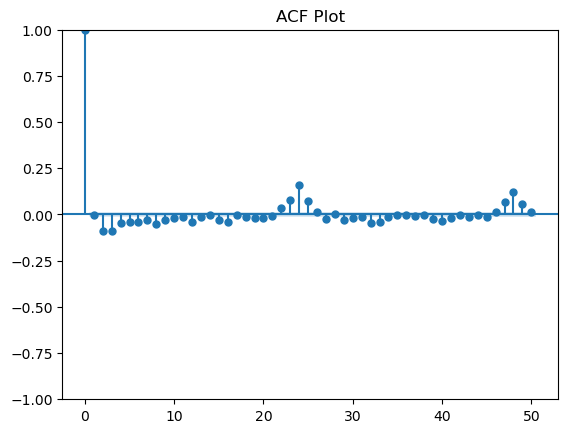

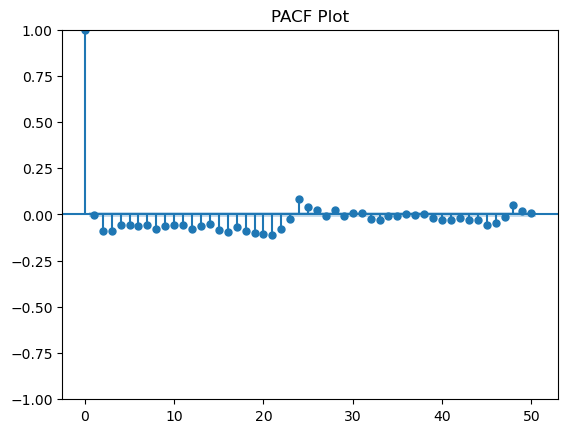

In [45]:
plot_acf(arima_train, lags=50)
plt.title('ACF Plot')
plt.show()

plot_pacf(arima_train, lags=50)
plt.title('PACF Plot')
plt.show()

#### Baseline ARIMA

In [46]:
# Initial ARIMA order from ACF/PACF analysis
order = (1, 0, 1)

initial_arima = ARIMA(arima_train, order=order)
initial_arima_fit = initial_arima.fit()

print(initial_arima_fit.summary())

c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:            delta_price   No. Observations:                31207
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -182785.130
Date:                Sun, 29 Mar 2026   AIC                         365578.260
Time:                        15:26:55   BIC                         365611.653
Sample:                             0   HQIC                        365588.954
                              - 31207                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0010      0.030     -0.034      0.973      -0.060       0.058
ar.L1          0.8279      0.002    341.672      0.000       0.823       0.833
ma.L1         -0.9933      0.001  -1941.020      0.0

#### ARIMA Tuning


In [47]:
#candidate_orders = [
#    (1, 0, 0),
#    (1, 0, 1),
#    (2, 0, 0),
#    (2, 0, 1),
#    (1, 0, 2),
#    (2, 0, 2)
#]
#
#results = []
#
#for o in candidate_orders:
#    try:
#        arima_model = ARIMA(arima_train, order=o).fit()
#        arima_pred = arima_model.forecast(steps=len(arima_val))
#        arima_pred = pd.Series(arima_pred.values, index=arima_val.index)
#
#        arima_mae_o = mean_absolute_error(arima_val, arima_pred)
#        arima_rmse_o = np.sqrt(mean_squared_error(arima_val, arima_pred))
#        arima_mape_o = (np.abs((arima_val - arima_pred) / arima_val.replace(0, np.nan))).mean() * 100
#
#        results.append((o, arima_mae_o, arima_rmse_o, arima_mape_o))
#    except Exception as e:
#        print(f"Order {o} failed: {e}")
#
#arima_results_df = pd.DataFrame(results, columns=['order', 'MAE', 'RMSE', 'MAPE']).sort_values('RMSE')
#print(arima_results_df)
#
#best_order = arima_results_df.iloc[0]['order']
#print("Best ARIMA Order:", best_order)

**Best ARIMA Order: (1, 0, 1)**

#### ARIMA Validation

c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generat

ARIMA[1, 0, 1] 1-Step-Ahead Validation Metrics (full validation set)
----------------------------------------------------------
MAE:  33.6386
MSE:  4977.5520
RMSE: 70.5518


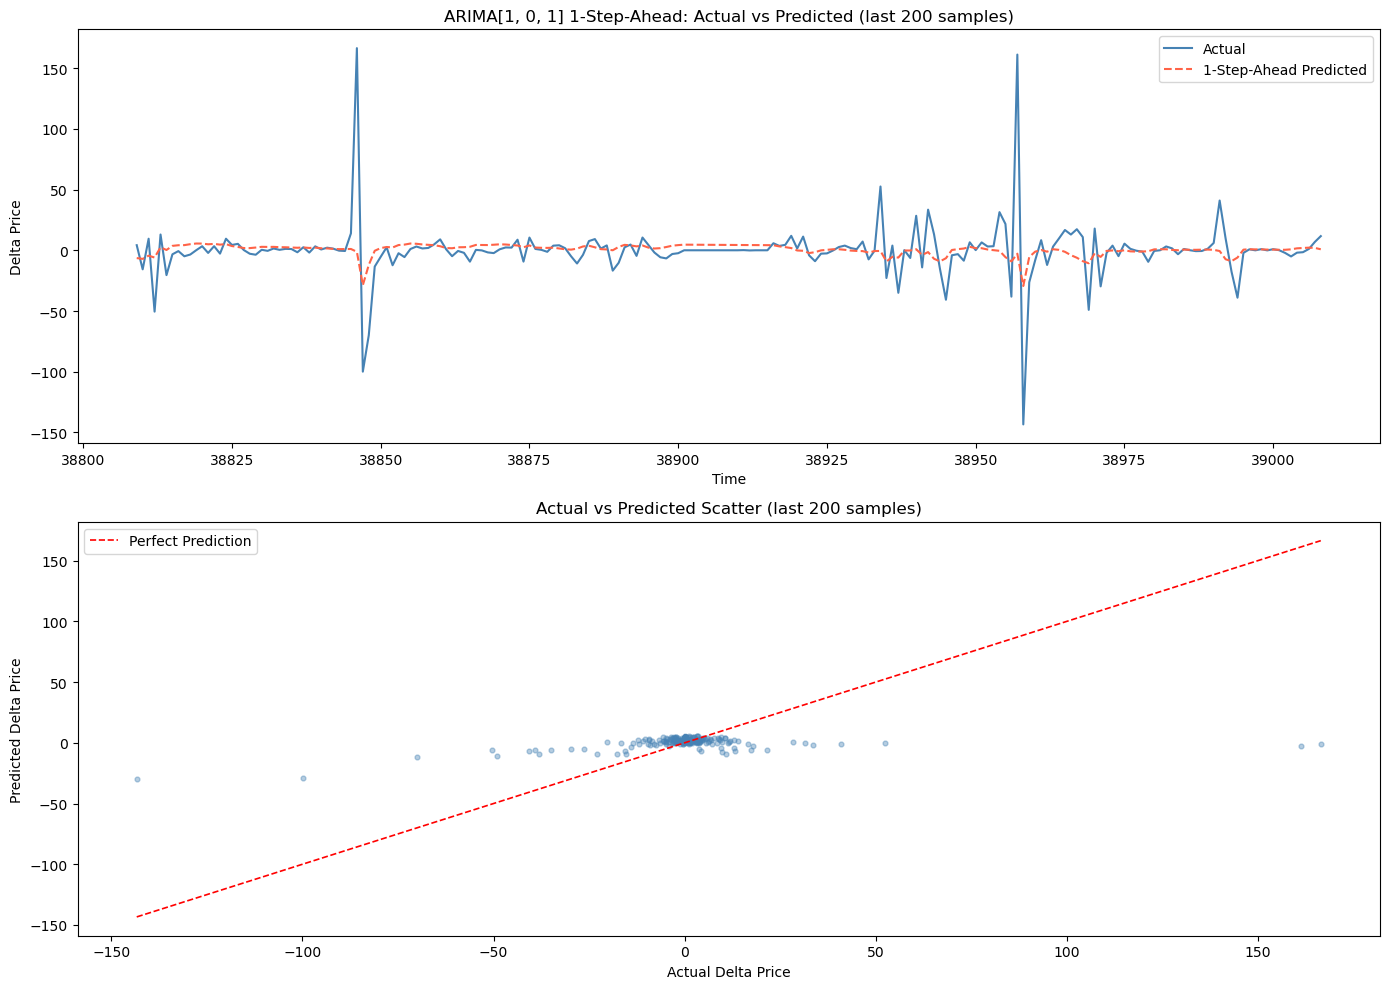

In [48]:
best_order = [1,0,1]
# 1-step-ahead validation using fixed parameters 
model = ARIMA(arima_train, order=best_order)
fit   = model.fit()
arima_rolling_forecast = fit.extend(arima_val).fittedvalues

# --- Metrics (full validation set) ---
arima_mae  = mean_absolute_error(arima_val, arima_rolling_forecast)
arima_mse  = mean_squared_error(arima_val, arima_rolling_forecast)
arima_rmse = np.sqrt(arima_mse)

print(f'ARIMA{best_order} 1-Step-Ahead Validation Metrics (full validation set)')
print('-' * 58)
print(f'MAE:  {arima_mae:.4f}')
print(f'MSE:  {arima_mse:.4f}')
print(f'RMSE: {arima_rmse:.4f}')

# --- Plot last 200 samples only ---
actual_plot   = arima_val.iloc[-200:]
forecast_plot = arima_rolling_forecast.iloc[-200:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(actual_plot.index, actual_plot.values, label='Actual', color='steelblue')
axes[0].plot(forecast_plot.index, forecast_plot.values,
             label='1-Step-Ahead Predicted', color='tomato', linestyle='--')
axes[0].set_title(f'ARIMA{best_order} 1-Step-Ahead: Actual vs Predicted (last 200 samples)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Delta Price')
axes[0].legend()

axes[1].scatter(actual_plot.values, forecast_plot.values,
                alpha=0.4, color='steelblue', s=12)
lims = [min(actual_plot.min(), forecast_plot.min()),
        max(actual_plot.max(), forecast_plot.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted Scatter (last 200 samples)')
axes[1].set_xlabel('Actual Delta Price')
axes[1].set_ylabel('Predicted Delta Price')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Lasso Regression - Cynthia

#### Prepare Data for training Lasso

In [49]:
# Create a copy of the original data for modeling
lasso_df = data.copy()

# Drop Unnecessary Columns
drop_cols = ["Date_Begin_Local", "ACTUAL_POOL_PRICE"] # Was used for EDA and Reference, but not needed for modeling
lasso_df = lasso_df.drop(columns=drop_cols)

# Extract Target
lasso_X = lasso_df.drop(columns=["delta_price"])
lasso_y = lasso_df["delta_price"]

# Static Train-Val Split
# Chronological train / validation split
split_ratio = 0.8
split_index = int(len(lasso_df) * split_ratio)

lasso_X_train = lasso_X.iloc[:split_index].copy()
lasso_X_val = lasso_X.iloc[split_index:].copy()

lasso_y_train = lasso_y.iloc[:split_index].copy()
lasso_y_val = lasso_y.iloc[split_index:].copy()

# Scale features
# Lasso requires standardized predictors

scaler = StandardScaler()

lasso_X_train_scaled = scaler.fit_transform(lasso_X_train)
lasso_X_val_scaled = scaler.transform(lasso_X_val)

print("Scaled lasso_X_train shape:", lasso_X_train_scaled.shape)
print("Scaled lasso_X_val shape:", lasso_X_val_scaled.shape)

Scaled lasso_X_train shape: (31207, 17)
Scaled lasso_X_val shape: (7802, 17)


#### Tuning LASSO


In [50]:
# Tune LASSO with Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

lasso_cv = LassoCV(
    alphas=np.logspace(-6, 1, 80),
    cv=tscv,
    max_iter=30000,
    random_state=42
)

lasso_cv.fit(lasso_X_train_scaled, lasso_y_train)

best_alpha = lasso_cv.alpha_
print("Best alpha selected by LassoCV:", best_alpha)

Best alpha selected by LassoCV: 0.026938893095901698


Train LASSO

In [51]:
# Fit final LASSO model
lasso_model = Lasso(alpha=best_alpha, max_iter=30000)
lasso_model.fit(lasso_X_train_scaled, lasso_y_train)

# Make validation predictions
lasso_val_pred = lasso_model.predict(lasso_X_val_scaled)

print("First 10 validation predictions:")
print(lasso_val_pred[:10])

First 10 validation predictions:
[ 52.13088793  24.0757005  -11.18332539 -51.86621525 -34.42534918
 -19.60053515  31.01402093  43.68933675  64.89070228   8.68573875]


#### Validation

In [52]:
# Validation metrics

lasso_val_mae = mean_absolute_error(lasso_y_val, lasso_val_pred)
lasso_val_rmse = np.sqrt(mean_squared_error(lasso_y_val, lasso_val_pred))

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100

lasso_val_smape = smape(lasso_y_val, lasso_val_pred)

print("LASSO VALIDATION MAE:", lasso_val_mae)
print("LASSO VALIDATION RMSE:", lasso_val_rmse)
print("LASSO VALIDATION sMAPE:", lasso_val_smape)

LASSO VALIDATION MAE: 34.98053975696759
LASSO VALIDATION RMSE: 68.78782770133205
LASSO VALIDATION sMAPE: 145.55716757498692


Lasso Coefficients Analysis

In [53]:
# Coefficient Table
# Lasso shrinks some coefficients to zero

coef_df = pd.DataFrame({
    'Feature': lasso_X_train.columns,
    'Coefficient': lasso_model.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 20 Lasso coefficients:")
print(coef_df.head(20))

# Count selected and removed features

non_zero_coefs = (coef_df['Coefficient'] != 0).sum()
zero_coefs = (coef_df['Coefficient'] == 0).sum()

print("Number of selected features (non-zero coefficients):", non_zero_coefs)
print("Number of removed features (zero coefficients):", zero_coefs)

Top 20 Lasso coefficients:
                 Feature  Coefficient  Abs_Coefficient
1                T2M_AVG   -41.626784        41.626784
10               AIL_T2M    39.365248        39.365248
2            price_lag_1   -37.780576        37.780576
3           price_lag_24    14.519180        14.519180
9                 T2M_sq     8.802525         8.802525
6            is_low_wind     7.896352         7.896352
12              hour_cos    -6.957250         6.957250
4          price_lag_168     6.029970         6.029970
16             month_cos     3.885877         3.885877
0             ACTUAL_AIL    -2.786210         2.786210
13               dow_sin     2.488257         2.488257
7       wind_power_proxy    -2.225627         2.225627
14               dow_cos     1.903468         1.903468
11              hour_sin     1.348509         1.348509
15             month_sin     1.253698         1.253698
5   price_rolling_std_24     0.468161         0.468161
8           is_cold_snap     0.432946 

#### Plots for intepretation

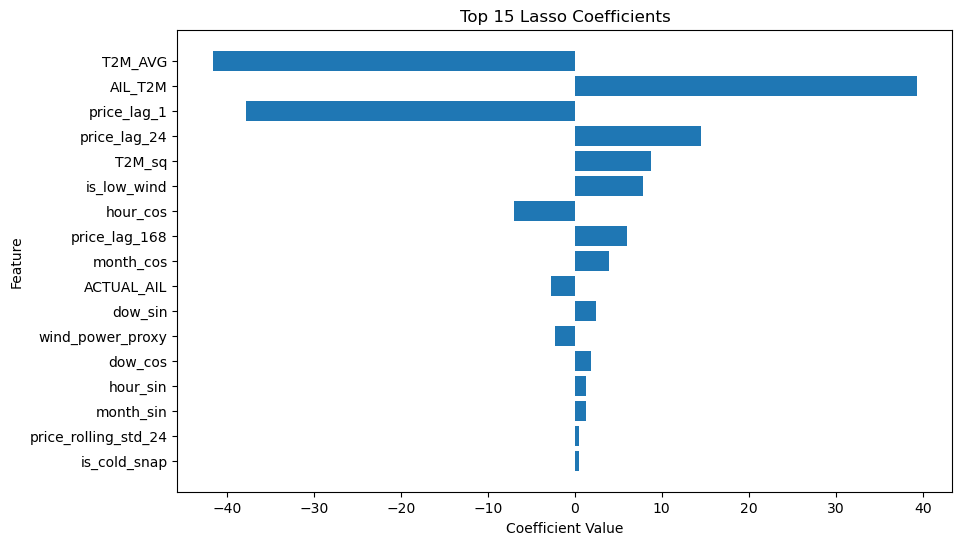

In [54]:
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title('Top 15 Lasso Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

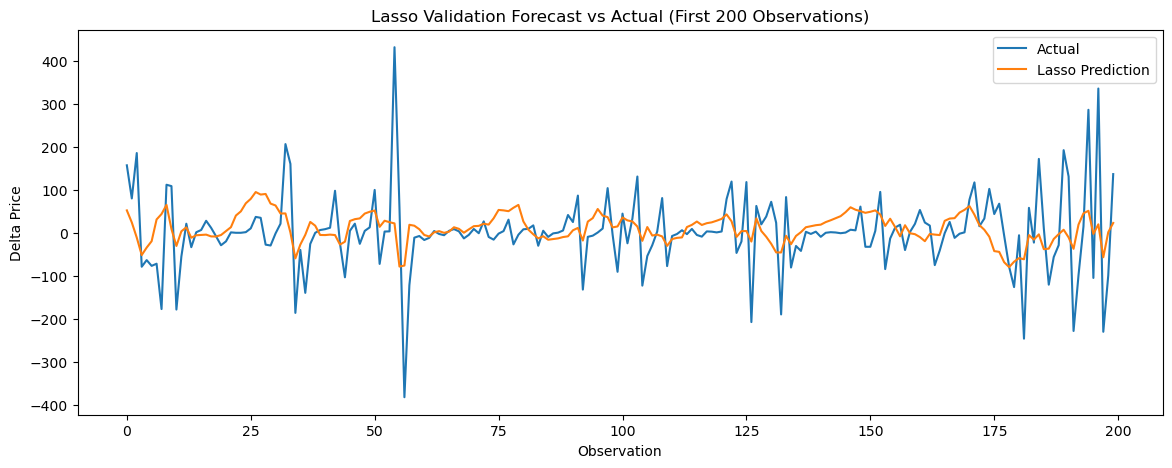

In [55]:
# Plot actual VS predicted on validation set

plt.figure(figsize=(14, 5))
plt.plot(lasso_y_val.iloc[:200].values, label='Actual')
plt.plot(lasso_val_pred[:200], label='Lasso Prediction')
plt.title('Lasso Validation Forecast vs Actual (First 200 Observations)')
plt.xlabel('Observation')
plt.ylabel('Delta Price')
plt.legend()
plt.show()

## 4. LSTM Model training and tuning - Thaison

### i. Preparing Dataset for LSTM

In [76]:
# Create a copy of the original data for modeling
lstm_df = data.copy()
# Drop Unnecessary Columns
drop_cols = ["Date_Begin_Local", "ACTUAL_POOL_PRICE"] # Was used for EDA and Reference, but not needed for modeling
lstm_df = lstm_df.drop(columns=drop_cols)

# Extract Target Variable
X = lstm_df.drop(columns=["delta_price"])
y = lstm_df["delta_price"]

# Static Train-Val Split
split =0.8
split_index = int(len(X) * split)
X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

### ii. Training LSTM Model

#### Helper classes-functions

In [77]:
# Time series loader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, lookback):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        X_seq = self.X[idx : idx + self.lookback]
        y_seq = self.y[idx + self.lookback]
        return X_seq, y_seq
    
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]
        lstm_out = self.dropout(lstm_out)
        lstm_out = self.fc(lstm_out)
        return lstm_out.squeeze(-1)
    
class EarlyStopping:
    def __init__(self, patience, min_delta):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1

        return self.counter >= self.patience
    
# Feature Scaling
scaler = StandardScaler()

#### Model SETUP

In [104]:
# Scale features
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Hyperparameters
LOOKBACK = 48
BATCHSIZE = 32
INPUT_SIZE = X_train_scaled.shape[1]
HIDDEN_SIZE = 32
NUM_LAYERS = 2
DROPOUT = 0.4
LEARNING_RATE = 0.00491

# Create datasets
train_dataset = TimeSeriesDataset(X_train_scaled, y_train, LOOKBACK)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val, LOOKBACK)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCHSIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCHSIZE, shuffle=False)

# Initialize model, loss function, and optimizer
model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# SETUP Logs:
print(f"Train sequences : {len(train_dataset)}")
print(f"Validation sequences : {len(val_dataset)}")
print(f"Sequence shape  : ({LOOKBACK}, {X_train_scaled.shape[1]})")
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Train sequences : 31159
Validation sequences : 7754
Sequence shape  : (48, 17)
LSTMModel(
  (lstm): LSTM(17, 32, num_layers=2, batch_first=True, dropout=0.4)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Trainable params: 15,009


#### Training

In [105]:
train_losses = []
val_losses = []
EPOCHS = 100

early_stopping = EarlyStopping(patience=15, min_delta=0)

for epoch in range(EPOCHS):
    # Training Pass -----
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        # Reset gradients
        optimizer.zero_grad()
        # Forward pass
        fw_pass_outputs = model(X_batch)
        # Compute loss
        loss = loss_function(fw_pass_outputs, y_batch)
        # Backward pass
        loss.backward()
        # Gradient clipping (Keep gradients in check)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Update weights
        optimizer.step()
        # Accumulate loss
        epoch_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation Pass -----
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            val_pass_outputs = model(X_batch)
            loss = loss_function(val_pass_outputs, y_batch)
            epoch_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    if early_stopping(epoch_val_loss, model):
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)
    print(f"Best val loss: {early_stopping.best_loss:.4f}")
else:
    print("Warning: no best state saved.")

Epoch 1/100 - Train Loss: 7605.5728 - Val Loss: 5100.7257
Epoch 2/100 - Train Loss: 7347.7199 - Val Loss: 4899.6905
Epoch 3/100 - Train Loss: 7159.3839 - Val Loss: 4790.0781
Epoch 4/100 - Train Loss: 7085.6418 - Val Loss: 4677.2751
Epoch 5/100 - Train Loss: 6978.6971 - Val Loss: 4610.8578
Epoch 6/100 - Train Loss: 6860.3363 - Val Loss: 4607.1615
Epoch 7/100 - Train Loss: 6774.9101 - Val Loss: 4558.7467
Epoch 8/100 - Train Loss: 6750.4404 - Val Loss: 4561.6532
Epoch 9/100 - Train Loss: 6661.9107 - Val Loss: 4578.1394
Epoch 10/100 - Train Loss: 6680.3993 - Val Loss: 4560.8593
Epoch 11/100 - Train Loss: 6630.4791 - Val Loss: 4581.2002
Epoch 12/100 - Train Loss: 6639.4228 - Val Loss: 4509.6691
Epoch 13/100 - Train Loss: 6604.7059 - Val Loss: 4482.1610
Epoch 14/100 - Train Loss: 6530.1566 - Val Loss: 4577.3022
Epoch 15/100 - Train Loss: 6502.6047 - Val Loss: 4534.5380
Epoch 16/100 - Train Loss: 6556.5164 - Val Loss: 4562.1481
Epoch 17/100 - Train Loss: 6460.9176 - Val Loss: 4463.8653
Epoch 

#### Tuning

In [ ]:
## ── Hyperparameter Tuning with Optuna ───────────────────────────────────────
## Run this cell ONCE to find optimal hyperparameters, then comment it out.
## Searches: hidden_size, dropout, learning_rate  |  Fixed: num_layers=2, lookback=48
## Budget: ~2-3 hours on CPU (timeout=9000s, up to 25 trials)
## ─────────────────────────────────────────────────────────────────────────────
#import optuna
#import time
#import torch
#import torch.nn as nn
#from sklearn.preprocessing import StandardScaler
#from torch.utils.data import DataLoader
#optuna.logging.set_verbosity(optuna.logging.WARNING)
#
## ── Fixed during search ───────────────────────────────────────────────────────
#_LOOKBACK    = 48
#_BATCHSIZE   = 32
#_NUM_LAYERS  = 2
#_MAX_EPOCHS  = 60   # per trial — enough to see convergence, short enough for budget
#_ES_PATIENCE = 8    # aggressive early stopping per trial to kill bad configs fast
#
## ── Pre-build loaders once — reused by every trial ───────────────────────────
#_scaler = StandardScaler()
#_X_train_s = _scaler.fit_transform(X_train)
#_X_val_s   = _scaler.transform(X_val)
#
#_train_ds  = TimeSeriesDataset(_X_train_s, y_train, _LOOKBACK)
#_val_ds    = TimeSeriesDataset(_X_val_s,   y_val,   _LOOKBACK)
#_train_ldr = DataLoader(_train_ds, batch_size=_BATCHSIZE, shuffle=False)
#_val_ldr   = DataLoader(_val_ds,   batch_size=_BATCHSIZE, shuffle=False)
#
#_INPUT_SIZE = _X_train_s.shape[1]   # 25
#
#def objective(trial):
#    # ── Search space ─────────────────────────────────────────────────────────
#    # hidden_size: 3 candidates — small/medium/large for a ~31k sequence dataset
#    # dropout:     0.1–0.5 in 0.05 steps — wide enough to catch under/over-regularisation
#    # lr:          log-uniform 1e-4 to 5e-3 — Adam sweet spot for LSTMs
#    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
#    dropout     = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
#    lr          = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
#
#    model          = LSTMModel(_INPUT_SIZE, hidden_size, _NUM_LAYERS, dropout)
#    loss_fn        = nn.MSELoss()
#    optimizer      = torch.optim.Adam(model.parameters(), lr=lr)
#    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(
#                         optimizer, mode="min", factor=0.5, patience=5)
#    early_stopping = EarlyStopping(patience=_ES_PATIENCE, min_delta=0)
#
#    for epoch in range(_MAX_EPOCHS):
#        # Training pass
#        model.train()
#        for X_batch, y_batch in _train_ldr:
#            optimizer.zero_grad()
#            loss = loss_fn(model(X_batch), y_batch)
#            loss.backward()
#            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#            optimizer.step()
#
#        # Validation pass
#        model.eval()
#        epoch_val_loss = 0
#        with torch.no_grad():
#            for X_batch, y_batch in _val_ldr:
#                epoch_val_loss += loss_fn(model(X_batch), y_batch).item() * X_batch.size(0)
#        epoch_val_loss /= len(_val_ldr.dataset)
#
#        scheduler.step(epoch_val_loss)
#
#        # Optuna pruning — kill clearly bad trials after epoch 5
#        trial.report(epoch_val_loss, epoch)
#        if trial.should_prune():
#            raise optuna.exceptions.TrialPruned()
#
#        if early_stopping(epoch_val_loss, model):
#            break
#
#    return early_stopping.best_loss
#
## ── Run the study ─────────────────────────────────────────────────────────────
## TPESampler: Bayesian search — smarter than random after the first few trials
## MedianPruner: prune a trial if its val loss is worse than the median at that epoch
#study = optuna.create_study(
#    direction="minimize",
#    sampler=optuna.samplers.TPESampler(seed=42),
#    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
#)
#
#print("Starting Optuna search — budget: 2.5 hrs / 25 trials")
#print(f"Search space: hidden_size=[32,64,128]  dropout=[0.10-0.50]  lr=[1e-4, 5e-3]")
#print("-" * 60)
#
#start = time.time()
#study.optimize(
#    objective,
#    n_trials=25,
#    timeout=18000,          # hard stop at 2.5 hours regardless of trial count
#    show_progress_bar=True
#)
#
#elapsed = (time.time() - start) / 60
#completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
#pruned    = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
#
#print("" + "=" * 60)
#print("  Optuna Search Complete")
#print("=" * 60)
#print(f"  Elapsed     : {elapsed:.1f} min")
#print(f"  Trials done : {len(study.trials)}  (completed={completed}, pruned={pruned})")
#print(f"  Best val loss: {study.best_value:.4f}")
#print("=" * 60)
#print("  BEST HYPERPARAMETERS")
#print("=" * 60)
#for k, v in study.best_params.items():
#    print(f"  {k:<15}: {v}")
#print("=" * 60)




c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting Optuna search — budget: 2.5 hrs / 25 trials
Search space: hidden_size=[32,64,128]  dropout=[0.10-0.50]  lr=[1e-4, 5e-3]
------------------------------------------------------------


Best trial: 22. Best value: 4421.18: 100%|██████████| 25/25 [1:17:36<00:00, 186.26s/it, 4656.47/18000 seconds]

  Optuna Search Complete
  Elapsed     : 77.6 min
  Trials done : 25  (completed=12, pruned=13)
  Best val loss: 4421.1789
  BEST HYPERPARAMETERS
  hidden_size    : 32
  dropout        : 0.45000000000000007
  lr             : 0.004915608098093081


**Best params**:

hidden_size: 32

dropout: 0.45

lr: 0.00491


#### Model Validation Eval

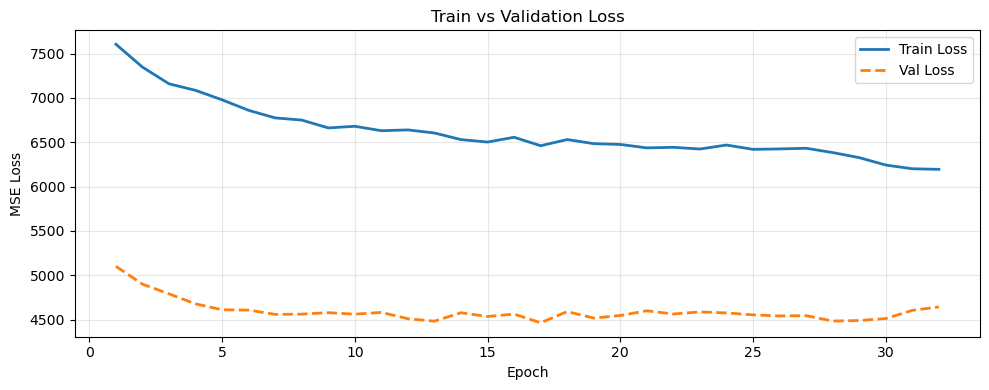

   Validation Metrics
  MSE:   4463.8653 $/MWh²
  RMSE:    66.8122 $/MWh
  MAE:     30.0801 $/MWh
   Naive Baseline Metrics
Naive MAE:  31.2402 $/MWh
Naive RMSE: 73.0483 $/MWh


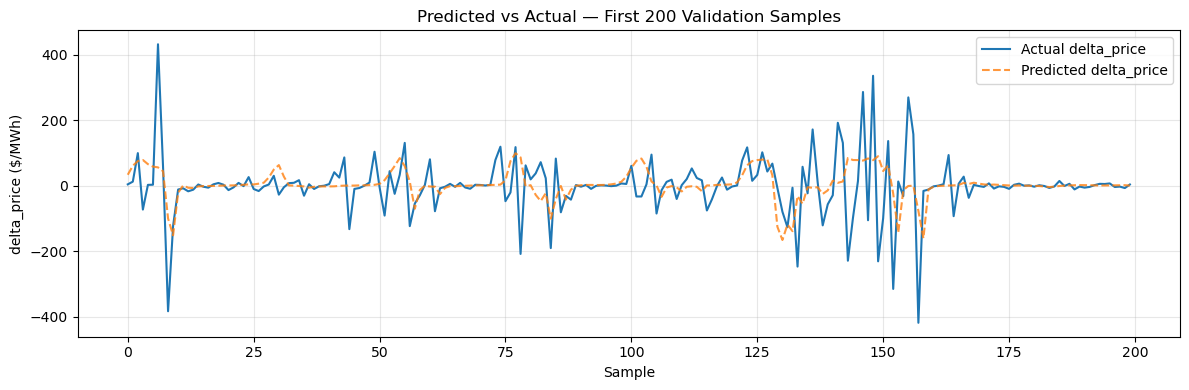

In [106]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# ── 1. Train vs Val Loss Curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
epochs_ran = range(1, len(train_losses) + 1)

ax.plot(epochs_ran, train_losses, label="Train Loss", linewidth=2)
ax.plot(epochs_ran, val_losses,   label="Val Loss",   linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Train vs Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Collect predictions on validation set ─────────────────────────────
model.eval()
all_preds   = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        preds = model(X_batch)
        all_preds.extend(preds.numpy())
        all_targets.extend(y_batch.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

# ── 3. RMSE ──────────────────────────────────────────────────────────────
rmse = mean_squared_error(all_targets, all_preds) ** 0.5
mae = mean_absolute_error(all_targets, all_preds)

# ── 4. Print metrics ─────────────────────────────────────────────────────
print("=" * 40)
print("   Validation Metrics")
print("=" * 40)
print(f"  MSE:  {early_stopping.best_loss:>10.4f} $/MWh²")
print(f"  RMSE: {rmse:>10.4f} $/MWh")
print(f"  MAE:  {mae:>10.4f} $/MWh")
print("=" * 40)
# Naive baseline: delta_price = 0 (predict no change)
naive_mae  = np.mean(np.abs(all_targets))
naive_rmse = np.std(all_targets)
print("=" * 40)
print("   Naive Baseline Metrics")
print("=" * 40)
print(f"Naive MAE:  {naive_mae:.4f} $/MWh")
print(f"Naive RMSE: {naive_rmse:.4f} $/MWh")
print("=" * 40)
# ── 5. Predicted vs Actual plot (first 200 samples) ─────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(all_targets[:200], label="Actual delta_price",    linewidth=1.5)
ax.plot(all_preds[:200],   label="Predicted delta_price", linewidth=1.5, linestyle="--", alpha=0.8)
ax.set_xlabel("Sample")
ax.set_ylabel("delta_price ($/MWh)")
ax.set_title("Predicted vs Actual — First 200 Validation Samples")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Model Showdown LSTM vs. LASSO vs. ARIMA - Thaison

- All 3 models will be retrained on the entire train set

## 5.1 Load Test Data

In [107]:
# Load test data
test_path = "C:\\Users\\sonla\\Documents\\EnergyPrices\\Data\\test.csv"
test_data = pd.read_csv(test_path)
print(f"Test set shape: {test_data.shape}")
test_data.head()


Test set shape: (9753, 20)


,Date_Begin_Local,ACTUAL_POOL_PRICE,ACTUAL_AIL,T2M_AVG,price_lag_1,price_lag_24,price_lag_168,price_rolling_std_24,is_low_wind,wind_power_proxy,is_cold_snap,T2M_sq,AIL_T2M,delta_price,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,2024-06-20 14:00:00,53.37,10187.0,19.656667,37.39,27.99,25.68,17.295228,1,23.639903,0,386.384544,200242.463333,15.98,-0.500000,-8.660254e-01,0.433884,-0.900969,1.224647e-16,-1.0
1,2024-06-20 15:00:00,28.26,10177.0,20.040000,53.37,28.04,27.05,17.762464,1,24.982449,0,401.601600,203947.080000,-25.11,-0.707107,-7.071068e-01,0.433884,-0.900969,1.224647e-16,-1.0
2,2024-06-20 16:00:00,25.94,10110.0,20.183333,28.26,27.34,26.74,17.759426,1,27.910037,0,407.366944,204053.500000,-2.32,-0.866025,-5.000000e-01,0.433884,-0.900969,1.224647e-16,-1.0
3,2024-06-20 17:00:00,20.59,10105.0,20.076667,25.94,26.75,26.17,17.783835,1,29.313079,0,403.072544,202874.716667,-5.35,-0.965926,-2.588190e-01,0.433884,-0.900969,1.224647e-16,-1.0
4,2024-06-20 18:00:00,17.58,10038.0,19.800000,20.59,28.03,40.11,17.932895,1,31.654457,0,392.040000,198752.400000,-3.01,-1.000000,-1.836970e-16,0.433884,-0.900969,1.224647e-16,-1.0


## 5.2 ARIMA — Full Retrain + Test Evaluation

In [108]:
# ── 5.2 ARIMA: Full Retrain + Test Evaluation ────────────────────────────────
best_order = [1,0,1]
final_arima = ARIMA(arima_y, order=best_order).fit()
arima_test_y = test_data['delta_price'].dropna().reset_index(drop=True)
arima_test_y.index = pd.RangeIndex(len(arima_y), len(arima_y) + len(arima_test_y))

arima_test_forecast = final_arima.extend(arima_test_y).fittedvalues

arima_test_mae   = mean_absolute_error(arima_test_y, arima_test_forecast)
arima_test_rmse  = np.sqrt(mean_squared_error(arima_test_y, arima_test_forecast))
arima_test_smape = smape(arima_test_y.values, arima_test_forecast.values)

print(f"ARIMA{best_order} Test MAE:   {arima_test_mae:.4f}")
print(f"ARIMA{best_order} Test RMSE:  {arima_test_rmse:.4f}")
print(f"ARIMA{best_order} Test sMAPE: {arima_test_smape:.4f}%")


ARIMA[1, 0, 1] Test MAE:   18.8113
ARIMA[1, 0, 1] Test RMSE:  59.4520
ARIMA[1, 0, 1] Test sMAPE: 150.3072%


c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\sonla\miniforge3\envs\ml-torch\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


## 5.3 LASSO — Full Retrain + Test Evaluation

In [109]:
# ── 5.3 LASSO: Full Retrain + Test Evaluation ────────────────────────────────
# Retrain on all of train.csv (lasso_X / lasso_y defined in Section 3)
lasso_full_scaler   = StandardScaler()
lasso_full_X_scaled = lasso_full_scaler.fit_transform(lasso_X)

lasso_final = Lasso(alpha=best_alpha, max_iter=30000)
lasso_final.fit(lasso_full_X_scaled, lasso_y)

# Test set — same feature set as LASSO (drop Date_Begin_Local & ACTUAL_POOL_PRICE)
test_lasso_df   = test_data.copy().drop(columns=["Date_Begin_Local", "ACTUAL_POOL_PRICE"])
test_lasso_X    = test_lasso_df.drop(columns=["delta_price"])
test_lasso_y    = test_lasso_df["delta_price"]
y_test_array    = test_lasso_y.values   # shared reference used in comparison plot

test_lasso_X_scaled = lasso_full_scaler.transform(test_lasso_X)
lasso_test_pred     = lasso_final.predict(test_lasso_X_scaled)

lasso_test_mae   = mean_absolute_error(test_lasso_y, lasso_test_pred)
lasso_test_rmse  = np.sqrt(mean_squared_error(test_lasso_y, lasso_test_pred))
lasso_test_smape = smape(test_lasso_y.values, lasso_test_pred)

print(f"LASSO Test MAE:   {lasso_test_mae:.4f}")
print(f"LASSO Test RMSE:  {lasso_test_rmse:.4f}")
print(f"LASSO Test sMAPE: {lasso_test_smape:.4f}%")


LASSO Test MAE:   25.0725
LASSO Test RMSE:  59.2603
LASSO Test sMAPE: 151.1633%


## 5.4 LSTM — Full Retrain + Test Evaluation

In [116]:
# ── 5.4 LSTM: Full Retrain on train.csv ──────────────────────────────────────
lstm_show_df = data.copy().drop(columns=["Date_Begin_Local", "ACTUAL_POOL_PRICE"])
X_full       = lstm_show_df.drop(columns=["delta_price"])
y_full       = lstm_show_df["delta_price"]

lstm_full_scaler = StandardScaler()
X_full_scaled    = lstm_full_scaler.fit_transform(X_full)

# Test features — scaled with the full-train scaler
test_lstm_df  = test_data.copy().drop(columns=["Date_Begin_Local", "ACTUAL_POOL_PRICE"])
X_test        = test_lstm_df.drop(columns=["delta_price"])
y_test        = test_lstm_df["delta_price"]
X_test_scaled = lstm_full_scaler.transform(X_test)

# Full training dataset and loader
full_train_dataset = TimeSeriesDataset(X_full_scaled, y_full, LOOKBACK)
full_train_loader  = DataLoader(full_train_dataset, batch_size=BATCHSIZE, shuffle=False)

# New model with the same best hyperparameters
lstm_showdown = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
loss_fn_show  = nn.MSELoss()
opt_show      = torch.optim.Adam(lstm_showdown.parameters(), lr=LEARNING_RATE)
sched_show    = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_show, mode='min', factor=0.5, patience=10)

# Retrain for the same number of epochs that early-stopping chose during validation
n_retrain_epochs = len(train_losses)
print(f"Retraining LSTM for {n_retrain_epochs} epochs on full training data ...")

for epoch in range(n_retrain_epochs):
    lstm_showdown.train()
    epoch_loss = 0.0
    for X_batch, y_batch in full_train_loader:
        opt_show.zero_grad()
        preds = lstm_showdown(X_batch)
        loss  = loss_fn_show(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_showdown.parameters(), max_norm=1.0)
        opt_show.step()
        epoch_loss += loss.item() * X_batch.size(0)
    epoch_loss /= len(full_train_loader.dataset)
    sched_show.step(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{n_retrain_epochs} — Train Loss: {epoch_loss:.4f}")

print("LSTM retraining complete.")


Retraining LSTM for 32 epochs on full training data ...
  Epoch 10/32 — Train Loss: 6222.1875
  Epoch 20/32 — Train Loss: 6089.6368
  Epoch 30/32 — Train Loss: 6097.7275
LSTM retraining complete.


In [117]:
# ── LSTM: Test Predictions ────────────────────────────────────────────────────
# Prepend last LOOKBACK rows of training data to provide sequence context
X_context      = np.concatenate([X_full_scaled[-LOOKBACK:], X_test_scaled], axis=0)
y_context      = np.concatenate([np.zeros(LOOKBACK), y_test.values])
y_context_ser  = pd.Series(y_context)

lstm_test_dataset = TimeSeriesDataset(X_context, y_context_ser, LOOKBACK)
lstm_test_loader  = DataLoader(lstm_test_dataset, batch_size=BATCHSIZE, shuffle=False)

lstm_showdown.eval()
lstm_test_preds   = []
lstm_test_targets = []

with torch.no_grad():
    for X_batch, y_batch in lstm_test_loader:
        preds = lstm_showdown(X_batch)
        lstm_test_preds.extend(preds.numpy())
        lstm_test_targets.extend(y_batch.numpy())

lstm_test_preds   = np.array(lstm_test_preds)
lstm_test_targets = np.array(lstm_test_targets)

lstm_test_mae   = mean_absolute_error(lstm_test_targets, lstm_test_preds)
lstm_test_rmse  = np.sqrt(mean_squared_error(lstm_test_targets, lstm_test_preds))
lstm_test_smape = smape(lstm_test_targets, lstm_test_preds)

print(f"LSTM Test MAE:   {lstm_test_mae:.4f}")
print(f"LSTM Test RMSE:  {lstm_test_rmse:.4f}")
print(f"LSTM Test sMAPE: {lstm_test_smape:.4f}%")


LSTM Test MAE:   17.2428
LSTM Test RMSE:  56.5579
LSTM Test sMAPE: 148.6484%


## 5.5 Model Comparison

       Model Showdown — Test Set Results
  (Peak_RMSE_99: |delta_price| > 326.73)
       Model       MAE      RMSE  Peak_RMSE_99
ARIMA(1,0,1) 18.811288 59.452029    470.630581
       LASSO 25.072507 59.260329    446.292200
        LSTM 17.242825 56.557853    439.699240


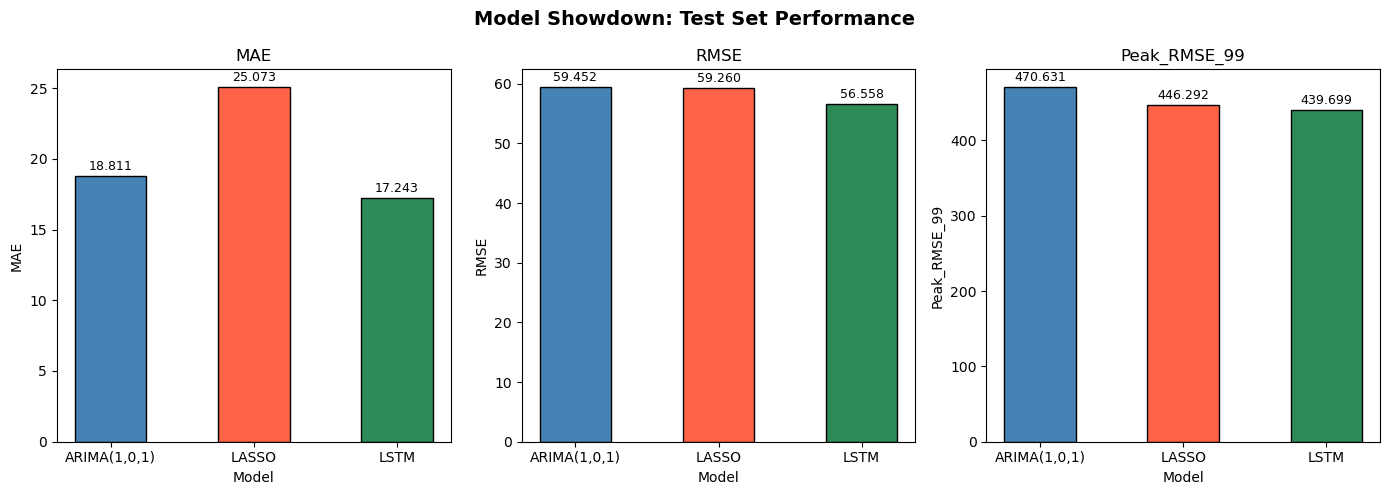

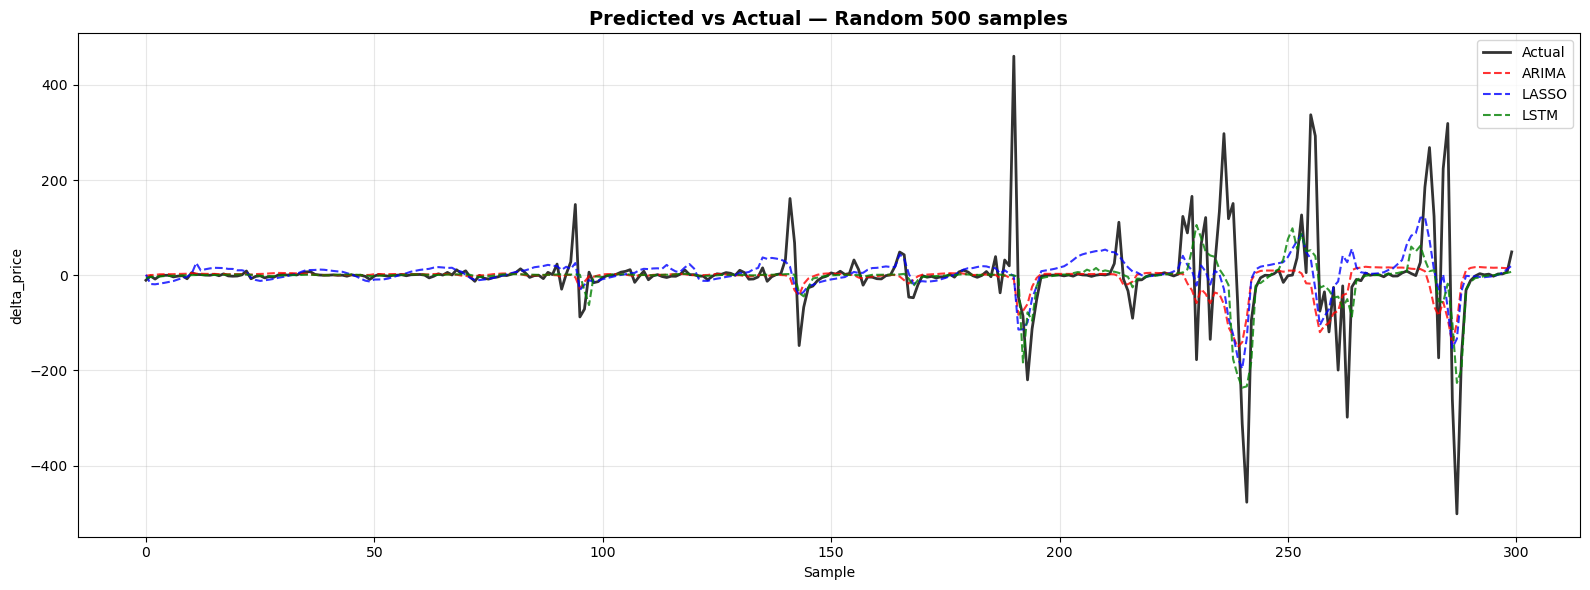

In [131]:
# ── Model Showdown Summary ───────────────────────────────────────────────────

# Compute conditional RMSE at 99th percentile (peak times)
threshold_99 = np.abs(test_lasso_y).quantile(0.99)

arima_peak_mask_99 = np.abs(arima_test_y.values) > threshold_99
lasso_peak_mask_99 = np.abs(test_lasso_y.values) > threshold_99
lstm_peak_mask_99  = np.abs(lstm_test_targets) > threshold_99

arima_peak_rmse_99 = np.sqrt(mean_squared_error(
    arima_test_y.values[arima_peak_mask_99], 
    arima_test_forecast.values[arima_peak_mask_99]
))
lasso_peak_rmse_99 = np.sqrt(mean_squared_error(
    test_lasso_y.values[lasso_peak_mask_99], 
    lasso_test_pred[lasso_peak_mask_99]
))
lstm_peak_rmse_99 = np.sqrt(mean_squared_error(
    lstm_test_targets[lstm_peak_mask_99], 
    lstm_test_preds[lstm_peak_mask_99]
))

results = pd.DataFrame({
    'Model': ['ARIMA(1,0,1)', 'LASSO', 'LSTM'],
    'MAE':   [arima_test_mae,  lasso_test_mae,  lstm_test_mae],
    'RMSE':  [arima_test_rmse, lasso_test_rmse, lstm_test_rmse],
    'Peak_RMSE_99': [arima_peak_rmse_99, lasso_peak_rmse_99, lstm_peak_rmse_99],
})

print("=" * 60)
print("       Model Showdown — Test Set Results")
print(f"  (Peak_RMSE_99: |delta_price| > {threshold_99:.2f})")
print("=" * 60)
print(results.to_string(index=False))
print("=" * 60)

# ── Bar-chart comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
bar_colors = ['steelblue', 'tomato', 'seagreen']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'Peak_RMSE_99']):
    bars = ax.bar(results['Model'], results[metric], color=bar_colors,
                  edgecolor='black', width=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Model Showdown: Test Set Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Predicted vs Actual (first 200 test samples) — All Models Overlay ────────
n_plot = len(y_test_array)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(arima_test_y.values[200:500], label='Actual', color='black', linewidth=2, alpha=0.8)
ax.plot(arima_test_forecast.values[200:500], label='ARIMA', color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax.plot(lasso_test_pred[200:500], label='LASSO', color='blue', linestyle='--', linewidth=1.5, alpha=0.8)
ax.plot(lstm_test_preds[200:500], label='LSTM', color='green', linestyle='--', linewidth=1.5, alpha=0.8)

ax.set_title('Predicted vs Actual — Random 500 samples', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample')
ax.set_ylabel('delta_price')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()